In [2]:
import numpy as np 
import pickle
import pandas as pd

loaded = np.load('connectomes_harm_compressed.npz')
connectomes_harm = loaded['connectomes']
with open('data_harm.pkl', 'rb') as f:
    data_harm = pickle.load(f)

In [3]:
# connectomes_harm is 3D (n_subjects, 90, 90), so reshape to 2D first

df_harm = pd.DataFrame(connectomes_harm.reshape(connectomes_harm.shape[0], -1))

df_harm['age'] = data_harm['age'].to_numpy()

df_harm.head()

df_harm.shape
df_harm.tail()



,0,1,2,3,4,5,6,7,8,9,...,8091,8092,8093,8094,8095,8096,8097,8098,8099,age
3797,0.0,0.000000,0.580083,0.058154,0.125389,0.000000,0.398513,0.0,0.015673,0.0,...,0.000000,0.0,0.0,0.0,0.524952,0.0,0.024535,0.0,0.0,38
3798,0.0,0.000000,0.020657,0.032556,0.167243,0.000000,0.156980,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.100876,0.0,0.025452,0.0,0.0,47
3799,0.0,0.227975,0.346221,0.178066,0.143092,0.155782,0.233376,0.0,0.199113,0.0,...,0.047532,0.0,0.0,0.0,0.182959,0.0,0.056780,0.0,0.0,41
3800,0.0,0.000000,0.252247,0.000000,0.068915,0.000000,0.042776,0.0,0.000000,0.0,...,0.000000,0.0,0.0,0.0,0.186812,0.0,0.000000,0.0,0.0,87
3801,0.0,0.000000,0.282014,0.000000,0.081989,0.000000,0.170989,0.0,0.050853,0.0,...,0.000000,0.0,0.0,0.0,0.425853,0.0,0.083945,0.0,0.0,54


In [4]:
df_harm['age_group'] = pd.cut(df_harm['age'], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90], labels=['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90'])

age_group_counts = df_harm['age_group'].value_counts().sort_index()

#group by age group and calculate mean connectome for each group
grouped_means = df_harm.groupby('age_group').mean()


C:\Users\Ale\AppData\Local\Temp\ipykernel_11676\404967543.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_means = df_harm.groupby('age_group').mean()


In [5]:
grouped_means.shape
grouped_means


,0,1,2,3,4,5,6,7,8,9,...,8091,8092,8093,8094,8095,8096,8097,8098,8099,age
age_group,,,,,,,,,,,,,,,,,,,,,
0-10,0.0,0.062439,0.117395,0.019743,0.026693,0.005134,0.078697,0.000375,0.011065,0.000000,...,0.011391,0.000467,0.003508,0.000518,0.193750,0.002239,0.023371,0.004396,0.0,7.122340
10-20,0.0,0.098750,0.131330,0.034441,0.048028,0.028853,0.070862,0.000507,0.023953,0.000129,...,0.010849,0.000090,0.002372,0.000444,0.185705,0.001857,0.020563,0.002826,0.0,14.647619
20-30,0.0,0.093611,0.145955,0.032230,0.070529,0.037870,0.092977,0.001940,0.030526,0.000100,...,0.011855,0.000328,0.003530,0.000531,0.207388,0.001522,0.027785,0.007057,0.0,26.129268
30-40,0.0,0.119442,0.157478,0.040250,0.070420,0.050377,0.105034,0.002291,0.034742,0.000000,...,0.012170,0.000417,0.004489,0.000053,0.205387,0.001734,0.031715,0.004887,0.0,34.011152
40-50,0.0,0.129841,0.184313,0.054576,0.083076,0.064824,0.128853,0.003075,0.037894,0.000061,...,0.008820,0.000203,0.004896,0.000178,0.231697,0.000801,0.039946,0.004035,0.0,45.342412
50-60,0.0,0.098780,0.183899,0.041824,0.088887,0.043994,0.137598,0.000394,0.044666,0.000000,...,0.013693,0.000000,0.002593,0.000730,0.249263,0.001123,0.039151,0.003162,0.0,55.455645
60-70,0.0,0.064691,0.209192,0.024814,0.108743,0.034582,0.141872,0.000717,0.049630,0.000384,...,0.010688,0.000669,0.005227,0.000454,0.279243,0.001116,0.044211,0.003665,0.0,65.475983
70-80,0.0,0.028074,0.210134,0.011549,0.105617,0.018160,0.151660,0.001439,0.037257,0.000311,...,0.009093,0.000000,0.008627,0.000219,0.236588,0.000752,0.049645,0.001662,0.0,75.524887
80-90,0.0,0.015403,0.225271,0.006762,0.130288,0.008874,0.156958,0.000129,0.060511,0.000000,...,0.010350,0.000000,0.005331,0.000186,0.273933,0.003597,0.059766,0.002943,0.0,84.014085


In [6]:
grouped_means.to_csv('ESNcpp/average_connectomes_by_age_group.csv', index=False, header=False)

Correlation: 0.5009895337157844, P-value: 0.16949027497641286


Text(0, 0.5, 'Memory Capacity')

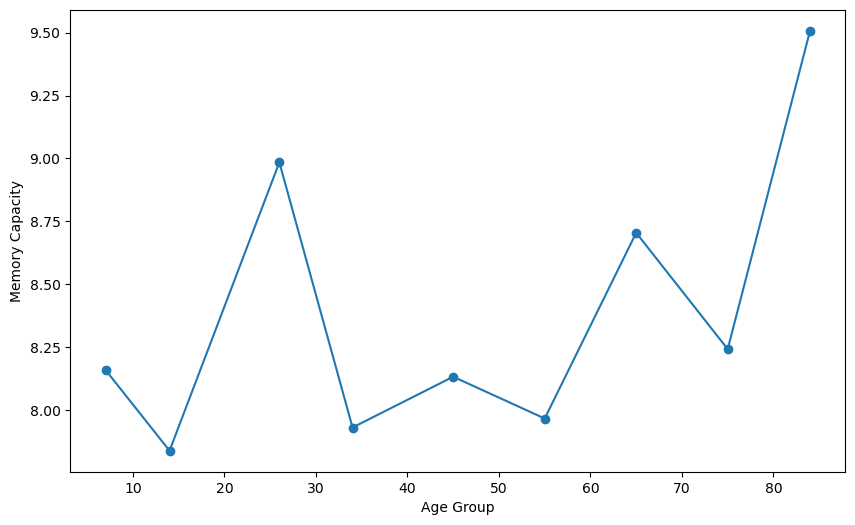

In [7]:
#start a dataframe with the correlations 
df = pd.read_csv('ESNcpp/MC_by_age_group.txt', header=None)
df.columns = ['Age Group', 'Memory Capacity']

#obtain a p value for the correlation between age group and memory capacity
from scipy.stats import pearsonr
correlation, p_value = pearsonr(df['Age Group'], df['Memory Capacity'])
print(f'Correlation: {correlation}, P-value: {p_value}')
#plot the correlation
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.plot(df['Age Group'], df['Memory Capacity'], marker='o')
plt.xlabel('Age Group')
plt.ylabel('Memory Capacity')

Doesnt seem to be promising, we are averaging connectomes and expecting that the avg of a hihgly non linear function is like the avg of the output of that function, so we are going to process all connectomes and perform memory task in them

In [8]:

df_harm = pd.DataFrame(connectomes_harm.reshape(connectomes_harm.shape[0], -1))

df_harm['age'] = data_harm['age'].to_numpy()

df_harm.head()

,0,1,2,3,4,5,6,7,8,9,...,8091,8092,8093,8094,8095,8096,8097,8098,8099,age
0,0.0,0.0,0.049047,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.161919,0.0,0.018394,0.0,0.0,0
1,0.0,0.0,0.161241,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,...,0.008886,0.0,0.0,0.0,0.095333,0.0,0.000000,0.0,0.0,0
2,0.0,0.0,0.230027,0.0,0.0,0.0,0.032053,0.0,0.0,0.0,...,0.031211,0.0,0.0,0.0,0.214103,0.0,0.095060,0.0,0.0,0
3,0.0,0.0,0.000000,0.0,0.0,0.0,0.031190,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.205546,0.0,0.000000,0.0,0.0,0
4,0.0,0.0,0.064553,0.0,0.0,0.0,0.021145,0.0,0.0,0.0,...,0.040969,0.0,0.0,0.0,0.555048,0.0,0.230462,0.0,0.0,0


In [9]:
#df_harm.to_csv('ESNcpp/connectomes_with_age.csv', index=False, header=False) 

actually as  test we can take random 30 and sort them by age

In [10]:
df_sample = df_harm.sample(n=1000, random_state=42)
df_sample.to_csv('ESNcpp/sample_connectomes_with_age_1000.csv', index=False, header=False)

Correlation: 0.17161067510923644, P-value: 0.08942406497396917


Text(0.5, 1.0, 'Correlation between Age Group and Memory Capacity, N=100')

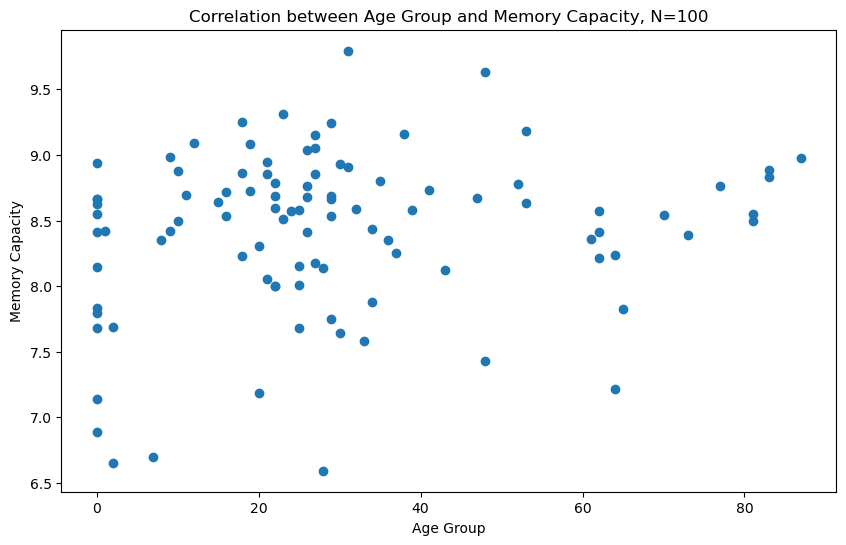

In [11]:
#start a dataframe with the correlations 
df = pd.read_csv('ESNcpp/MC_by_age_sample_100.txt', header=None)
df.columns = ['Age Group', 'Memory Capacity', 'NARMA10']

#obtain a p value for the correlation between age group and memory capacity
from scipy.stats import pearsonr
correlation, p_value = pearsonr(df['Age Group'], df['Memory Capacity'])
print(f'Correlation: {correlation}, P-value: {p_value}')
#plot the correlation
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(df['Age Group'], df['Memory Capacity'], marker='o')
plt.xlabel('Age Group')
plt.ylabel('Memory Capacity')
plt.title('Correlation between Age Group and Memory Capacity, N=100')

Correlation: 0.25888800039215454, P-value: 8.890045235322017e-17


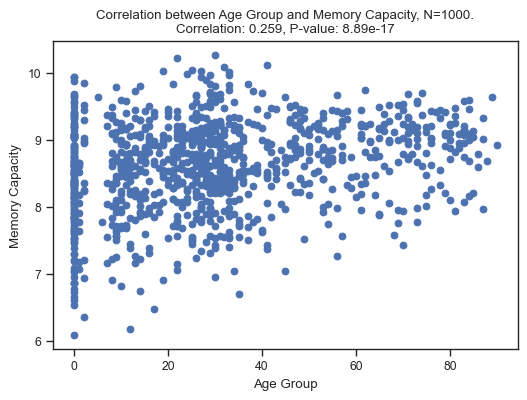

In [49]:
#start a dataframe with the correlations 
df = pd.read_csv('ESNcpp/MC_by_age_sample_1000.txt', header=None)
df.columns = ['Age Group', 'Memory Capacity']

#obtain a p value for the correlation between age group and memory capacity
from scipy.stats import pearsonr
correlation, p_value = pearsonr(df['Age Group'], df['Memory Capacity'])
print(f'Correlation: {correlation}, P-value: {p_value}')
#plot the correlation
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 4))
plt.scatter(df['Age Group'], df['Memory Capacity'], marker='o')
plt.xlabel('Age Group')
plt.ylabel('Memory Capacity')
plt.title(f'Correlation between Age Group and Memory Capacity, N=1000.\nCorrelation: {correlation:.3f}, P-value: {p_value:.2e}')
plt.savefig('results/ESN/correlation_age_memory_capacity_1000.png', dpi=300)

There are many of each age, we can maybe avg out by age? 

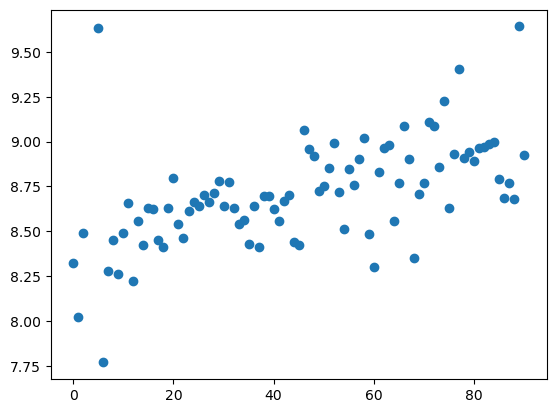

Correlation: 0.5675427900546511, P-value: 6.649194501110495e-09


In [13]:
df_by_age = (
    df.groupby('Age Group', as_index=False)['Memory Capacity']
      .mean()
      .sort_values('Age Group')
)

plt.scatter(df_by_age['Age Group'], df_by_age['Memory Capacity'], marker='o')
plt.show()

correlation, p_value = pearsonr(df_by_age['Age Group'], df_by_age['Memory Capacity'])
print(f'Correlation: {correlation}, P-value: {p_value}')


Questioning the hypothesis again, switch to NARMA which is more like Non linear

Correlation: -0.3138413455661121, P-value: 2.8390000464277953e-24


Text(0.5, 1.0, 'Correlation between Age Group and NARMA10, N=100')

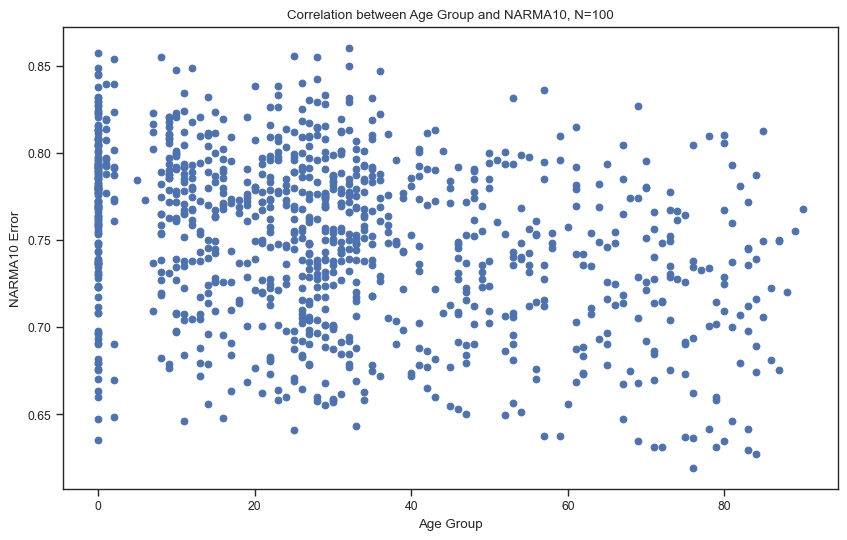

In [51]:
#start a dataframe with the correlations 
df = pd.read_csv('ESNcpp/MC_by_age_sample_100.txt', header=None)
df.columns = ['Age Group', 'Memory Capacity', 'NARMA10']

#obtain a p value for the correlation between age group and memory capacity
from scipy.stats import pearsonr
correlation, p_value = pearsonr(df['Age Group'], df['NARMA10'])
print(f'Correlation: {correlation}, P-value: {p_value}')
#plot the correlation
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(df['Age Group'], df['NARMA10'], marker='o')
plt.xlabel('Age Group')
plt.ylabel('NARMA10 Error' )
plt.title('Correlation between Age Group and NARMA10, N=100')

Seems to indicate the same thing. lower spectral gap in older brains leads to better "thinking". So we can try to use input regions as input for the ESN to see how well the signal propagates throuht the young less homogeneous brain and see if this tendency is reversed.

Correlation between Age Group and Memory Capacity: 0.24108648355648132, P-value: 1.1212587046129528e-14
Correlation between Age Group and NARMA10: -0.24929956817367133, P-value: 1.281918455772947e-15
Correlation between Age Group and Memory Capacity BIO ART INPUT: 0.32807912752467283, P-value: 1.6912240128341017e-26
Correlation between Age Group and NARMA10 BIO ART INPUT: -0.32640874416009863, P-value: 3.129300933230085e-26


Text(0.5, 1.0, 'Correlation between Age Group and Memory Capacity, N=1000, BIO ART INPUT')

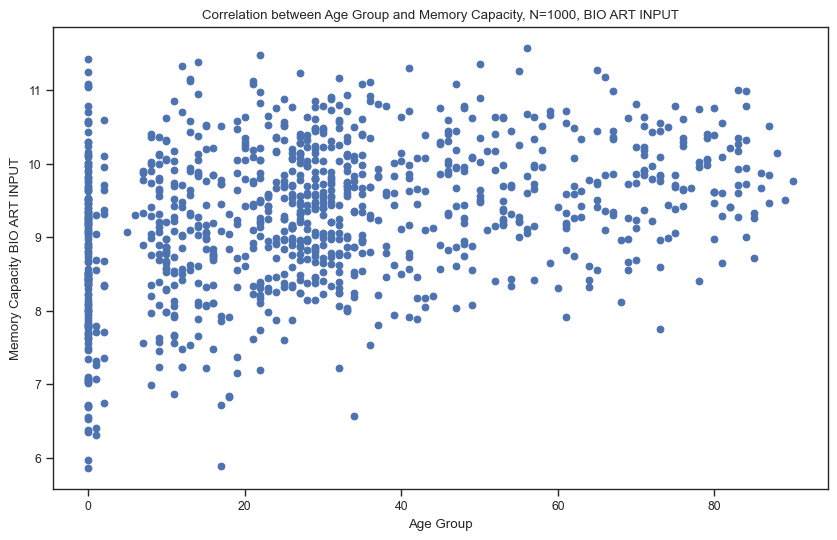

In [21]:
#start a dataframe with the correlations 
df = pd.read_csv('ESNcpp/MC_NARMA_bio_art_input.txt', header=None)
df.columns = ['Age Group', 'Memory Capacity', 'NARMA10', 'Memory Capacity BIO ART INPUT', 'NARMA10 BIO ART INPUT']

#obtain a p value for the correlation between age group and memory capacity
from scipy.stats import pearsonr
#calculate all pearson coeffs por all columns with age group
for col in df.columns[1:]:
     correlation, p_value = pearsonr(df['Age Group'], df[col])
     print(f'Correlation between Age Group and {col}: {correlation}, P-value: {p_value}')
#plot the correlation
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(df['Age Group'], df['Memory Capacity BIO ART INPUT'], marker='o')
plt.xlabel('Age Group')
plt.ylabel('Memory Capacity BIO ART INPUT' )
plt.title('Correlation between Age Group and Memory Capacity, N=1000, BIO ART INPUT')

C:\Users\Ale\AppData\Local\Temp\ipykernel_11676\2131444102.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res_df, x='r', y='Label', palette=colors, ax=ax, orient='h')


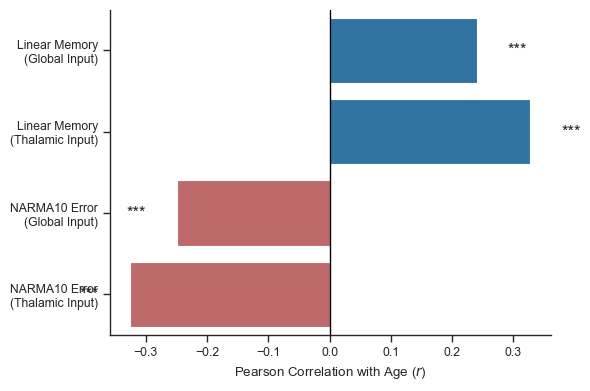

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# 1. Load and prepare data
df = pd.read_csv('ESNcpp/MC_NARMA_bio_art_input.txt', header=None)
df.columns = ['Age', 'MC_Art', 'NARMA_Art', 'MC_Bio', 'NARMA_Bio']

results = []
for m in ['MC_Art', 'MC_Bio', 'NARMA_Art', 'NARMA_Bio']:
    r, p = pearsonr(df['Age'], df[m])
    results.append({'Metric': m, 'r': r, 'p': p})
res_df = pd.DataFrame(results)

# Clean labels for the paper
label_map = {
    'MC_Art': 'Linear Memory\n(Global Input)',
    'MC_Bio': 'Linear Memory\n(Thalamic Input)',
    'NARMA_Art': 'NARMA10 Error\n(Global Input)',
    'NARMA_Bio': 'NARMA10 Error\n(Thalamic Input)'
}
res_df['Label'] = res_df['Metric'].map(label_map)

# 2. Assign significance stars
def get_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'
res_df['stars'] = res_df['p'].apply(get_stars)

# 3. Plotting
sns.set_theme(style="ticks", context="paper")
fig, ax = plt.subplots(figsize=(6, 4))

# Group colors by task (Blue for MC, Red for NARMA)
colors = ['tab:blue', 'tab:blue', 'indianred', 'indianred']
sns.barplot(data=res_df, x='r', y='Label', palette=colors, ax=ax, orient='h')

# Formatting
ax.axvline(0, color='black', linewidth=1)
for i, row in res_df.iterrows():
    align = 'left' if row['r'] > 0 else 'right'
    offset = 0.05 if row['r'] > 0 else -0.05
    ax.text(row['r'] + offset, i, row['stars'], va='center', ha=align, fontsize=12)

ax.set_xlabel(r'Pearson Correlation with Age ($r$)')
ax.set_ylabel('')
sns.despine()

plt.tight_layout()
plt.show()

Correlation between Age Group and Memory Capacity: 0.25075054707002664, P-value: 8.6668188153738545e-16
Correlation between Age Group and NARMA10: -0.3396341319927728, P-value: 2.1550367275081216e-28
Correlation between Age Group and Memory Capacity BIO ART INPUT: 0.3310204801936074, P-value: 5.669553154575077e-27
Correlation between Age Group and NARMA10 BIO ART INPUT: -0.28941277258162734, P-value: 9.954103803662593e-21


Text(0.5, 1.0, 'Correlation between Age Group and Memory Capacity, N=1000, BIO ART INPUT')

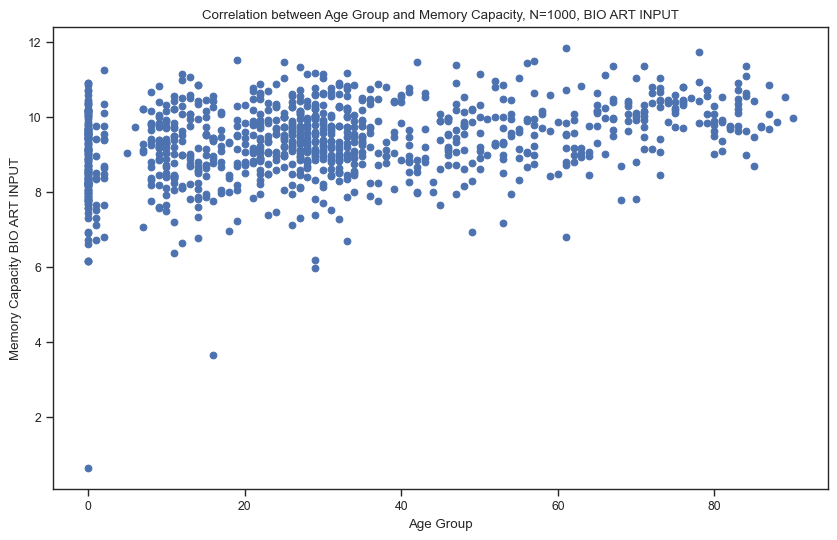

In [22]:
#start a dataframe with the correlations 
df = pd.read_csv('ESNcpp/MC_NARMA_bio_art_input_thalamus_constantInput.txt', header=None)
df.columns = ['Age Group', 'Memory Capacity', 'NARMA10', 'Memory Capacity BIO ART INPUT', 'NARMA10 BIO ART INPUT']

#obtain a p value for the correlation between age group and memory capacity
from scipy.stats import pearsonr
#calculate all pearson coeffs por all columns with age group
for col in df.columns[1:]:
     correlation, p_value = pearsonr(df['Age Group'], df[col])
     print(f'Correlation between Age Group and {col}: {correlation}, P-value: {p_value}')
#plot the correlation
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.scatter(df['Age Group'], df['Memory Capacity BIO ART INPUT'], marker='o')
plt.xlabel('Age Group')
plt.ylabel('Memory Capacity BIO ART INPUT' )
plt.title('Correlation between Age Group and Memory Capacity, N=1000, BIO ART INPUT')

So seeing this i asked gemini to come to tasks in which the young brain may be better

MC_Glob         | r:  0.2527 | p: 5.0852e-16
NARMA_Glob      | r: -0.3165 | p: 1.0945e-24
MC_Bio          | r:  0.3076 | p: 2.4504e-23
NARMA_Bio       | r: -0.3083 | p: 1.9396e-23
Multi_Glob      | r: -0.1716 | p: 4.8348e-08
Multi_Bio       | r: -0.3750 | p: 1.0502e-34
Hub_Glob        | r: -0.1321 | p: 2.8034e-05
Hub_Bio         | r: -0.3724 | p: 3.1837e-34
Time_Glob       | r:  0.1406 | p: 8.1336e-06
Time_Bio        | r: -0.1568 | p: 6.3504e-07
Fast_Glob       | r:  0.2278 | p: 3.1651e-13
Fast_Bio        | r:  0.1704 | p: 6.0235e-08


C:\Users\Ale\AppData\Local\Temp\ipykernel_11676\1982509161.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=res_df, x='r', y='Label', palette=colors, ax=ax, orient='h')


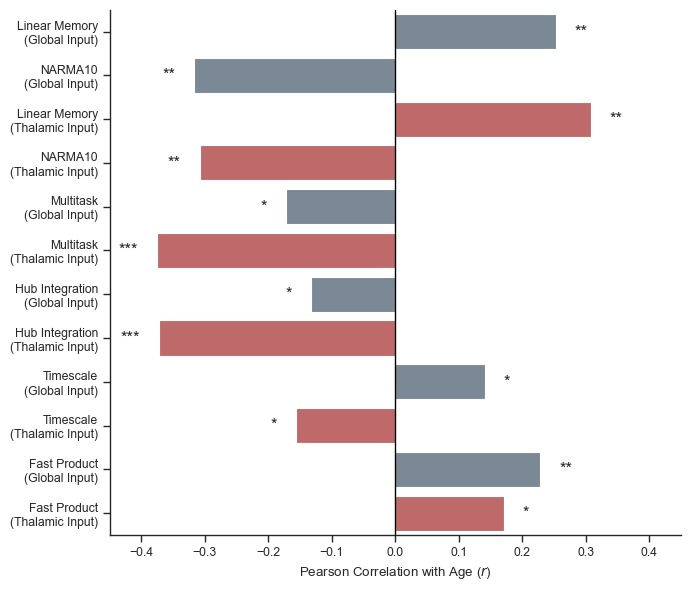

<Figure size 640x480 with 0 Axes>

In [58]:
df = pd.read_csv('ESNcpp/All_Tasks_Results.txt')

# 2. Calculate Pearson r and p-value for each metric vs Age
results = []
metrics = [col for col in df.columns if col != 'Age']

for col in metrics:
    r, p = pearsonr(df['Age'], df[col])
    results.append({'Metric': col, 'r': r, 'p': p})
    print(f"{col:<15} | r: {r:>7.4f} | p: {p:.4e}")

res_df = pd.DataFrame(results)

# 3. Clean labels for the paper
label_map = {
    'MC_Glob': 'Linear Memory\n(Global Input)',
    'MC_Bio': 'Linear Memory\n(Thalamic Input)',
    'NARMA_Glob': 'NARMA10\n(Global Input)',
    'NARMA_Bio': 'NARMA10\n(Thalamic Input)',
    'Multi_Glob': 'Multitask\n(Global Input)',
    'Multi_Bio': 'Multitask\n(Thalamic Input)',
    'Hub_Glob': 'Hub Integration\n(Global Input)',
    'Hub_Bio': 'Hub Integration\n(Thalamic Input)',
    'Time_Glob': 'Timescale\n(Global Input)',
    'Time_Bio': 'Timescale\n(Thalamic Input)',
    'Fast_Glob': 'Fast Product\n(Global Input)',
    'Fast_Bio': 'Fast Product\n(Thalamic Input)'
}
res_df['Label'] = res_df['Metric'].map(label_map)

# 4. Assign significance stars
def get_stars(p):
    if p < 1e-30: return '***'
    if p < 1e-10: return '**'
    if p < 1e-3: return '*'
    return ''

res_df['stars'] = res_df['p'].apply(get_stars)

# 5. Plotting (Paper Style: No title, compact size)
sns.set_theme(style="ticks", context="paper")
fig, ax = plt.subplots(figsize=(7, 6))

# Assign colors to differentiate Global (grey) vs Bio (red/blue)
colors = ['lightslategray' if 'Glob' in m else 'indianred' for m in res_df['Metric']]

sns.barplot(data=res_df, x='r', y='Label', palette=colors, ax=ax, orient='h')

# Formatting the plot
ax.axvline(0, color='black', linewidth=1)
ax.set_xlim(-1.2*max(abs(res_df['r'])), 1.2*max(abs(res_df['r'])))

# Add significance stars
for i, row in res_df.iterrows():
    align = 'left' if row['r'] > 0 else 'right'
    offset = 0.03 if row['r'] > 0 else -0.03
    ax.text(row['r'] + offset, i, row['stars'], va='center', ha=align, fontsize=12)

ax.set_xlabel(r'Pearson Correlation with Age ($r$)')
ax.set_ylabel('')
sns.despine()

plt.tight_layout()
plt.show()
plt.savefig('results/ESN/correlation_all_prediction_tasks.png', dpi=300)

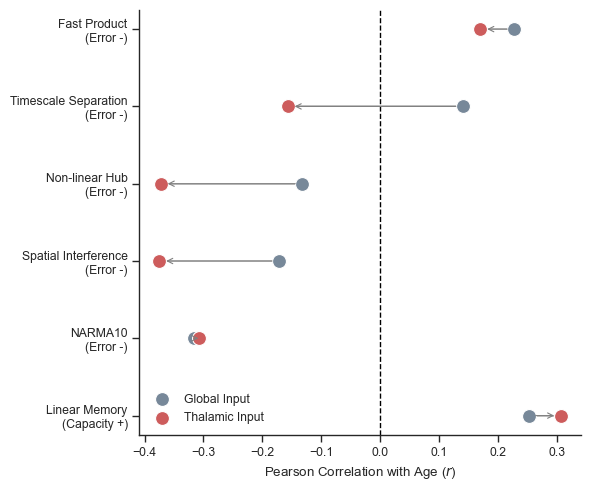

<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Load Data
df = pd.read_csv('ESNcpp/All_Tasks_Results.txt')

# 2. Compute Correlations
tasks = ['MC', 'NARMA', 'Multi', 'Hub', 'Time', 'Fast']
corrs = {'Task': [], 'Global': [], 'Bio': []}

for task in tasks:
    r_glob, _ = pearsonr(df['Age'], df[f'{task}_Glob'])
    r_bio, _ = pearsonr(df['Age'], df[f'{task}_Bio'])
    
    corrs['Task'].append(task)
    corrs['Global'].append(r_glob)
    corrs['Bio'].append(r_bio)

df_corr = pd.DataFrame(corrs)

# Clean labels for the y-axis
label_map = {
    'MC': 'Linear Memory\n(Capacity +)',
    'NARMA': 'NARMA10\n(Error -)',
    'Multi': 'Spatial Interference\n(Error -)',
    'Hub': 'Non-linear Hub\n(Error -)',
    'Time': 'Timescale Separation\n(Error -)',
    'Fast': 'Fast Product\n(Error -)'
}
df_corr['Task_Label'] = df_corr['Task'].map(label_map)

# 3. Plotting (Dumbbell Plot)
sns.set_theme(style="ticks", context="paper")
fig, ax = plt.subplots(figsize=(6, 5))

# Draw the lines connecting Global and Bio
ax.hlines(y=df_corr.index, xmin=df_corr['Global'], xmax=df_corr['Bio'], color='gray', alpha=0.5, zorder=1)

# Draw the points
sns.scatterplot(data=df_corr, x='Global', y=df_corr.index, color='lightslategray', s=100, label='Global Input', zorder=2, ax=ax)
sns.scatterplot(data=df_corr, x='Bio', y=df_corr.index, color='indianred', s=100, label='Thalamic Input', zorder=3, ax=ax)

# Draw arrows to emphasize the shift direction and magnitude
for i, row in df_corr.iterrows():
    ax.annotate('', xy=(row['Bio'], i), xytext=(row['Global'], i),
                arrowprops=dict(arrowstyle="->", color='gray', shrinkA=5, shrinkB=5))

# Formatting
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_yticks(df_corr.index)
ax.set_yticklabels(df_corr['Task_Label'])
ax.set_xlabel(r'Pearson Correlation with Age ($r$)')
ax.set_ylabel('')

# Legend adjustments
ax.legend(loc='lower left', frameon=False)
sns.despine()

plt.tight_layout()
plt.show()
plt.savefig('results/ESN/correlation_all_prediction_tasks_input_shift.png', dpi=300)

!! medir la disparity de las matrices de neuronas de salida. buscar otra tarea que beneficie a los jovenes. 
!!como cambia memory capacity con la edad para un solo tau. 

We can now try a classificaiton test. there are theoretical results indicating that the relation between memory capacity and separation property (Maass et al. 2002)

C:\Users\Ale\AppData\Local\Temp\ipykernel_11676\748106529.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(df['Age'], df[col])


Global Input                   | r:     nan | p: nan
Thalamic Input (2 nodes)       | r: -0.1885 | p: 1.9293e-09
Sensory Cortices (16 nodes)    | r: -0.1011 | p: 1.3701e-03


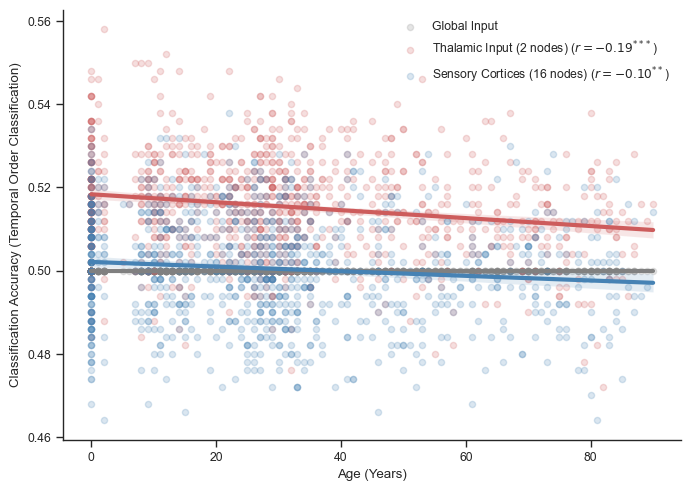

<Figure size 640x480 with 0 Axes>

In [ ]:
df = pd.read_csv('ESNcpp/Classification_Results_All.txt')

# 2. Calculate Correlations and P-values
metrics = {
    'Acc_Glob': ('Global Input', 'gray'),
    'Acc_Thal': ('Thalamic Input (2 nodes)', 'indianred'),
    'Acc_Sensory': ('Sensory Cortices (16 nodes)', 'steelblue')
}

def get_results(df, metrics):
    
    results = {}
    for col, (label, color) in metrics.items():
       r, p = pearsonr(df['Age'], df[col])
       results[col] = {'r': r, 'p': p, 'label': label, 'color': color}
       print(f"{label:<30} | r: {r:>7.4f} | p: {p:.4e}")
    return results

# Helper for significance stars in the legend
def get_stars(p):
    if p < 0.001: return '***'
    if p < 0.01: return '**'
    if p < 0.05: return '*'
    return 'ns'

# 3. Plotting
sns.set_theme(style="ticks", context="paper")
fig, ax = plt.subplots(figsize=(7, 5))

results = get_results(df, metrics)

# Plot each condition with its regression line
for col, info in results.items():
    label_str = f"{info['label']} ($r={info['r']:.2f}^{{{get_stars(info['p'])}}}$)" if info['label']!='Global Input' else info['label']
    sns.regplot(
        data=df, 
        x='Age', 
        y=col, 
        scatter_kws={'alpha': 0.2, 's': 20}, 
        line_kws={'linewidth': 3},
        color=info['color'], 
        label=label_str, 
        ax=ax
    )

# Formatting
ax.set_xlabel('Age (Years)')
ax.set_ylabel('Classification Accuracy (Temporal Order Classification)')
ax.legend(frameon=False, loc='best')

sns.despine()
plt.tight_layout()
plt.show()
plt.savefig('results/ESN/classification_tasks.png', dpi=300)

!reshuffling del valor de los links. como afecta. todos los links con ruido, variacion pequeña homogenea. como afecta. me cargo los weights. como afecta.

Thalamic Input (2 nodes)       | r:  0.0346 | p: 7.3363e-01
Sensory Cortices (16 nodes)    | r:  0.2326 | p: 2.0537e-02


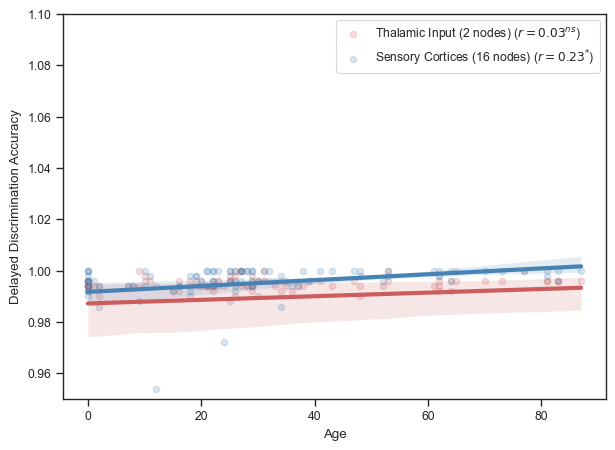

<Figure size 640x480 with 0 Axes>

In [ ]:
df=pd.read_csv('ESNcpp/Classification_Results_Delayed_Discrimination.txt')

metrics = {
    'Acc_Thal': ('Thalamic Input (2 nodes)', 'indianred'),
    'Acc_Sensory': ('Sensory Cortices (16 nodes)', 'steelblue')
}

results = get_results(df, metrics)
fig, ax = plt.subplots(figsize=(7, 5))
# Plot each condition with its regression line
for col, info in results.items():
    label_str = f"{info['label']} ($r={info['r']:.2f}^{{{get_stars(info['p'])}}}$)" if info['label']!='Global Input' else info['label']
    sns.regplot(
        data=df, 
        x='Age', 
        y=col, 
        scatter_kws={'alpha': 0.2, 's': 20}, 
        line_kws={'linewidth': 3},
        color=info['color'], 
        label=label_str, 
        ax=ax
    )
    

ax.set_ylabel('Delayed Discrimination Accuracy')
ax.set_ylim(0.95,1.1)
ax.legend()
plt.show()
plt.savefig('results/ESN/delayed_discrimination.png', dpi=300)

!quizas otra tarean en la que los jovenes mejores

C:\Users\Ale\AppData\Local\Temp\ipykernel_11676\748106529.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(df['Age'], df[col])


Global Input                   | r:     nan | p: nan
Thalamic Input (2 nodes)       | r:  0.2588 | p: 9.6923e-03
Sensory Cortices (16 nodes)    | r:  0.3766 | p: 1.2215e-04


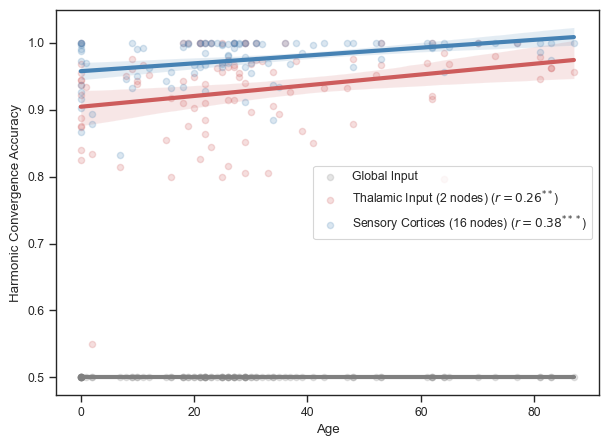

<Figure size 640x480 with 0 Axes>

In [76]:
df=pd.read_csv('ESNcpp/Classification_Results_Harmonic_Convergence.txt')

metrics = {
    'Acc_Glob': ('Global Input', 'gray'),
    'Acc_Thal': ('Thalamic Input (2 nodes)', 'indianred'),
    'Acc_Sensory': ('Sensory Cortices (16 nodes)', 'steelblue')
}

results = get_results(df, metrics)
fig, ax = plt.subplots(figsize=(7, 5))
# Plot each condition with its regression line
for col, info in results.items():
    label_str = f"{info['label']} ($r={info['r']:.2f}^{{{get_stars(info['p'])}}}$)" if info['label']!='Global Input' else info['label']
    sns.regplot(
        data=df, 
        x='Age', 
        y=col, 
        scatter_kws={'alpha': 0.2, 's': 20}, 
        line_kws={'linewidth': 3},
        color=info['color'], 
        label=label_str, 
        ax=ax
    )
    

ax.set_ylabel('Harmonic Convergence Accuracy')
#ax.set_ylim(0.95,1.1)
ax.legend()
plt.show()
plt.savefig('results/ESN/harmonic_convergence.png', dpi=300)

C:\Users\Ale\AppData\Local\Temp\ipykernel_11676\748106529.py:14: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = pearsonr(df['Age'], df[col])


Global Input                   | r:     nan | p: nan
Thalamic Input (2 nodes)       | r:     nan | p: nan
Sensory Cortices (16 nodes)    | r:     nan | p: nan


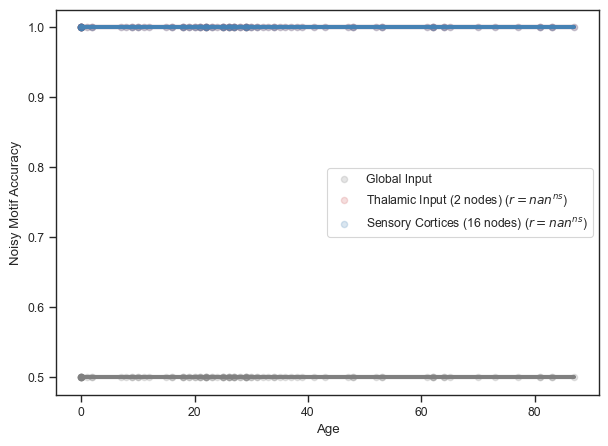

<Figure size 640x480 with 0 Axes>

In [78]:
df=pd.read_csv('ESNcpp/Classification_Results_Temporal_Smearing.txt')

metrics = {
    'Acc_Glob': ('Global Input', 'gray'),
    'Acc_Thal': ('Thalamic Input (2 nodes)', 'indianred'),
    'Acc_Sensory': ('Sensory Cortices (16 nodes)', 'steelblue')
}

results = get_results(df, metrics)
fig, ax = plt.subplots(figsize=(7, 5))
# Plot each condition with its regression line
for col, info in results.items():
    label_str = f"{info['label']} ($r={info['r']:.2f}^{{{get_stars(info['p'])}}}$)" if info['label']!='Global Input' else info['label']
    sns.regplot(
        data=df, 
        x='Age', 
        y=col, 
        scatter_kws={'alpha': 0.2, 's': 20}, 
        line_kws={'linewidth': 3},
        color=info['color'], 
        label=label_str, 
        ax=ax
    )
    

ax.set_ylabel('Noisy Motif Accuracy')
#ax.set_ylim(0.95,1.1)
ax.legend()
plt.show()
plt.savefig('results/ESN/noisy_motif.png', dpi=300)